Generating Graph 1: ROC Curve...


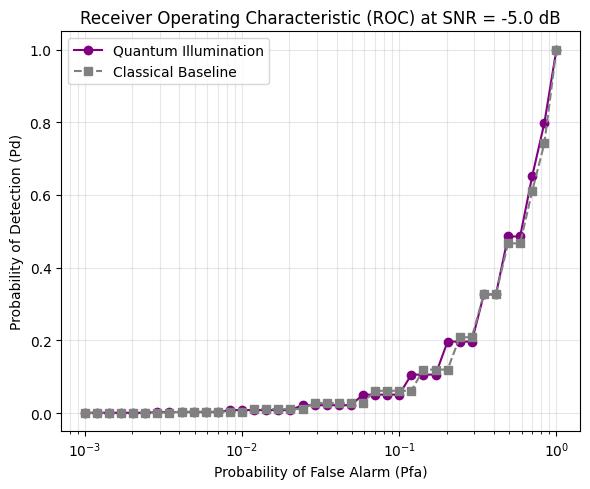

Generating Graph 2: Low-SNR Performance Profile...


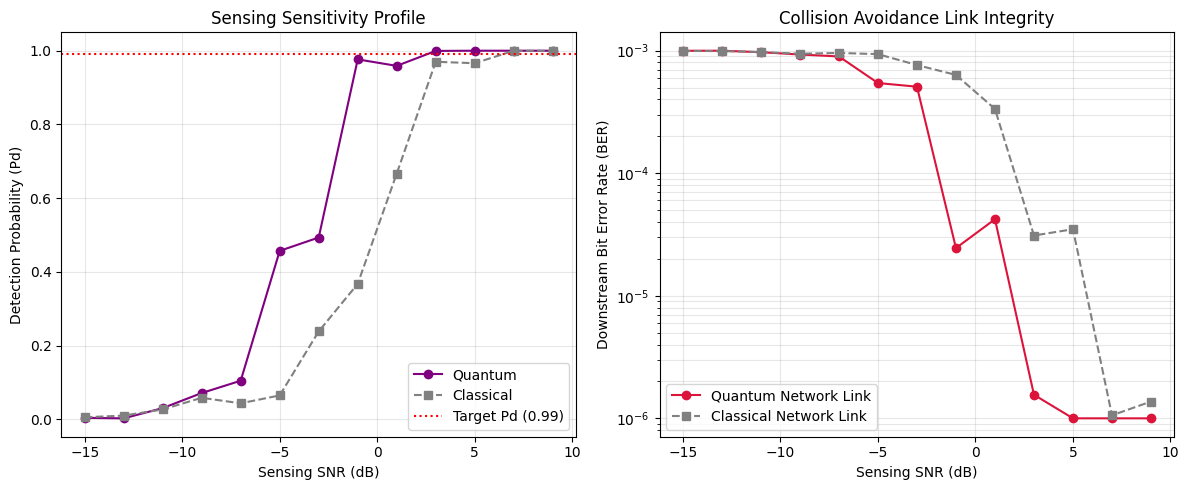

Generating Graph 3: Optimization Utility Surface vs Traffic Load...


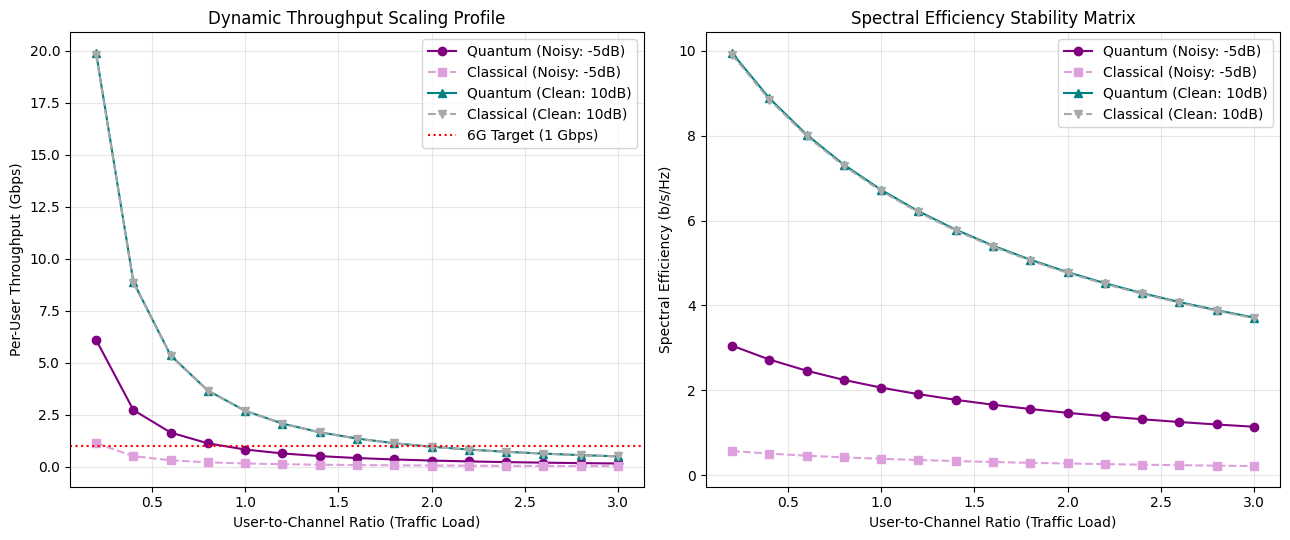

In [4]:
"""
qi_cognitive_radio_plots.py

Comprehensive evaluation script for Quantum Illumination vs. Classical Sensing
in 6G Cognitive Radio Spectrum Allocation. Generates performance figures:
1. ROC Curve (Sensing Layer)
2. Low-SNR Advantage Profile (Physical Layer vs Noise)
3. Network Utility & Throughput Profile (Allocation Layer vs Traffic Load)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Initialize backend
_BACKEND = AerSimulator()

# --- 6G CONSTANTS ---
TOTAL_BANDWIDTH_HZ = 2.0e9  
BASE_NUM_CHANNELS = 10000
CHANNEL_BANDWIDTH_HZ = TOTAL_BANDWIDTH_HZ / BASE_NUM_CHANNELS  
TARGET_PFA = 0.01
TARGET_SPECTRAL_EFFICIENCY = 10.0  
TARGET_BER_CLASSICAL = 1.0e-6
TARGET_THROUGHPUT_GBPS = 1.0       

def snr_db_to_ploss(snr_db, floor=0.02, ceiling=0.98):
    gamma = 10 ** (snr_db / 10.0)
    p_loss = 1.0 / (1.0 + gamma)
    return float(np.clip(p_loss, floor, ceiling))

def _run_counts(qc, p_dep, qubit, shots):
    nm = NoiseModel()
    nm.add_quantum_error(depolarizing_error(p_dep, 1), "id", [qubit])                # id is there because when travelling in the channel, no quantum gates, only noise
    qc_t = transpile(qc, basis_gates=["h", "cx", "id"], optimization_level=0)
    return _BACKEND.run(qc_t, shots=shots, noise_model=nm).result().get_counts()

def hit_probabilities(strategy, p_loss, shots=500):
    if strategy == "quantum":
        qc = QuantumCircuit(2, 2)
        qc.h(0); qc.cx(0, 1); qc.id(1); qc.cx(0, 1); qc.h(0); qc.measure([0, 1], [0, 1])            
        c_h0 = _run_counts(qc, 1.0, 1, shots)
        c_h1 = _run_counts(qc, p_loss, 1, shots)
        return c_h0.get("00", 0)/shots, c_h1.get("00", 0)/shots
    else:
        qc = QuantumCircuit(1, 1)
        qc.h(0); qc.id(0); qc.h(0); qc.measure(0, 0)
        c_h0 = _run_counts(qc, 1.0, 0, shots)
        c_h1 = _run_counts(qc, p_loss, 0, shots)
        return c_h0.get("0", 0)/shots, c_h1.get("0", 0)/shots

def pd_pfa_from_hit_probs(p0, p1, n_window, target_pfa):
    tau = n_window + 1
    for t in range(n_window + 1):
        pfa_t = 1.0 if t == 0 else binom.sf(t - 1, n_window, p0)
        if pfa_t <= target_pfa:
            tau = t
            break
    pfa = 1.0 if tau == 0 else binom.sf(tau - 1, n_window, p0)
    pd = 1.0 if tau == 0 else binom.sf(tau - 1, n_window, p1)
    return pd, pfa

def get_pd_pfa(snr_db, strategy="quantum", target_pfa=TARGET_PFA, n_window=30):
    p_loss = snr_db_to_ploss(snr_db)
    p0, p1 = hit_probabilities(strategy, p_loss)
    return pd_pfa_from_hit_probs(p0, p1, n_window, target_pfa)

def evaluate_metrics(pd, pfa, snr_db, ratio):
    # 1. Spectral efficiency degrades dynamically as users pack into the channel (ratio increases)
    congestion_penalty = 1.0 / (1.0 + 0.6 * (ratio - 0.2))
    se = TARGET_SPECTRAL_EFFICIENCY * pd * (1.0 - pfa) * congestion_penalty
    
    ber = TARGET_BER_CLASSICAL * (1.0 + (1.0 - pd) * 1000)
    
    # 2. Aggregated Component Carrier Bandwidth (e.g., 400 MHz) scaled down per user based on traffic load ratio
    user_allocated_bw = 400e6 / ratio  
    throughput_gbps = (user_allocated_bw * se) / 1e9
    
    return se, ber, throughput_gbps

# =====================================================================
# GENERATING GRAPH 1: ROC CURVE AT LOW SNR (-5 dB)
# =====================================================================
print("Generating Graph 1: ROC Curve...")
snr_roc = -5.0
p_loss_roc = snr_db_to_ploss(snr_roc)
q_p0, q_p1 = hit_probabilities("quantum", p_loss_roc)
c_p0, c_p1 = hit_probabilities("classical", p_loss_roc)

pfa_range = np.logspace(-3, 0, 40)
q_pd_series, c_pd_series = [], []

for t_pfa in pfa_range:
    _, q_pd = pd_pfa_from_hit_probs(q_p0, q_p1, n_window=30, target_pfa=t_pfa)
    _, c_pd = pd_pfa_from_hit_probs(c_p0, c_p1, n_window=30, target_pfa=t_pfa)
    q_pd_series.append(q_pd)
    c_pd_series.append(c_pd)

plt.figure(figsize=(6, 5))
plt.plot(pfa_range, q_pd_series, 'o-', color='purple', label='Quantum Illumination')
plt.plot(pfa_range, c_pd_series, 's--', color='gray', label='Classical Baseline')
plt.xscale('log')
plt.xlabel('Probability of False Alarm (Pfa)')
plt.ylabel('Probability of Detection (Pd)')
plt.title(f'Receiver Operating Characteristic (ROC) at SNR = {snr_roc} dB')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
# plt.savefig('graph1_roc_curve.png', dpi=150)
plt.show()  

# =====================================================================
# GENERATING GRAPH 2: LOW-SNR ADVANTAGE PROFILE (METRICS VS SNR)
# =====================================================================
print("Generating Graph 2: Low-SNR Performance Profile...")
snr_range = np.arange(-15, 11, 2)
q_pd_arr, c_pd_arr = [], []
q_ber_arr, c_ber_arr = [], []

for snr in snr_range:
    pq_d, pq_fa = get_pd_pfa(snr, "quantum")
    pc_d, pc_fa = get_pd_pfa(snr, "classical")
    
    _, q_ber, _ = evaluate_metrics(pq_d, pq_fa, snr, ratio=1.0)
    _, c_ber, _ = evaluate_metrics(pc_d, pc_fa, snr, ratio=1.0)
    
    q_pd_arr.append(pq_d)
    c_pd_arr.append(pc_d)
    q_ber_arr.append(q_ber)
    c_ber_arr.append(c_ber)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(snr_range, q_pd_arr, 'o-', color='purple', label='Quantum')
ax1.plot(snr_range, c_pd_arr, 's--', color='gray', label='Classical')
ax1.axhline(y=0.99, color='red', linestyle=':', label='Target Pd (0.99)')
ax1.set_xlabel('Sensing SNR (dB)')
ax1.set_ylabel('Detection Probability (Pd)')
ax1.set_title('Sensing Sensitivity Profile')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(snr_range, q_ber_arr, 'o-', color='crimson', label='Quantum Network Link')
ax2.plot(snr_range, c_ber_arr, 's--', color='gray', label='Classical Network Link')
ax2.set_yscale('log')
ax2.set_xlabel('Sensing SNR (dB)')
ax2.set_ylabel('Downstream Bit Error Rate (BER)')
ax2.set_title('Collision Avoidance Link Integrity')
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()
plt.tight_layout()
# plt.savefig('graph2_snr_advantage.png', dpi=150)
plt.show()  

# =====================================================================
# GENERATING GRAPH 3: OPTIMIZATION SURFACE (METRICS VS TRAFFIC LOAD RATIO)
# =====================================================================
print("Generating Graph 3: Optimization Utility Surface vs Traffic Load...")
ratio_range = np.linspace(0.2, 3.0, 15)
snr_clean = 10.0
snr_noisy = -5.0

q_pd_n, q_pfa_n = get_pd_pfa(snr_noisy, "quantum")
c_pd_n, c_pfa_n = get_pd_pfa(snr_noisy, "classical")
q_pd_c, q_pfa_c = get_pd_pfa(snr_clean, "quantum")
c_pd_c, c_pfa_c = get_pd_pfa(snr_clean, "classical")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

q_tp_n_arr, c_tp_n_arr, q_se_n_arr, c_se_n_arr = [], [], [], []
q_tp_c_arr, c_tp_c_arr, q_se_c_arr, c_se_c_arr = [], [], [], []

for r in ratio_range:
    q_se_n, _, q_tp_n = evaluate_metrics(q_pd_n, q_pfa_n, snr_noisy, r)
    c_se_n, _, c_tp_n = evaluate_metrics(c_pd_n, c_pfa_n, snr_noisy, r)
    q_se_c, _, q_tp_c = evaluate_metrics(q_pd_c, q_pfa_c, snr_clean, r)
    c_se_c, _, c_tp_c = evaluate_metrics(c_pd_c, c_pfa_c, snr_clean, r)
    
    q_tp_n_arr.append(q_tp_n); c_tp_n_arr.append(c_tp_n)
    q_tp_c_arr.append(q_tp_c); c_tp_c_arr.append(c_tp_c)
    q_se_n_arr.append(q_se_n); c_se_n_arr.append(c_se_n)
    q_se_c_arr.append(q_se_c); c_se_c_arr.append(c_se_c)

ax1.plot(ratio_range, q_tp_n_arr, 'o-', color='purple', label='Quantum (Noisy: -5dB)')
ax1.plot(ratio_range, c_tp_n_arr, 's--', color='plum', label='Classical (Noisy: -5dB)')
ax1.plot(ratio_range, q_tp_c_arr, '^-', color='teal', label='Quantum (Clean: 10dB)')
ax1.plot(ratio_range, c_tp_c_arr, 'v--', color='darkgray', label='Classical (Clean: 10dB)')
ax1.axhline(y=TARGET_THROUGHPUT_GBPS, color='red', linestyle=':', label='6G Target (1 Gbps)')
ax1.set_xlabel('User-to-Channel Ratio (Traffic Load)')
ax1.set_ylabel('Per-User Throughput (Gbps)')
ax1.set_title('Dynamic Throughput Scaling Profile')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(ratio_range, q_se_n_arr, 'o-', color='purple', label='Quantum (Noisy: -5dB)')
ax2.plot(ratio_range, c_se_n_arr, 's--', color='plum', label='Classical (Noisy: -5dB)')
ax2.plot(ratio_range, q_se_c_arr, '^-', color='teal', label='Quantum (Clean: 10dB)')
ax2.plot(ratio_range, c_se_c_arr, 'v--', color='darkgray', label='Classical (Clean: 10dB)')
ax2.set_xlabel('User-to-Channel Ratio (Traffic Load)')
ax2.set_ylabel('Spectral Efficiency (b/s/Hz)')
ax2.set_title('Spectral Efficiency Stability Matrix')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
# plt.savefig('graph3_optimization_surface.png', dpi=150)
plt.show()